#### Crude montecarlo

https://towardsdatascience.com/monte-carlo-simulations-with-python-part-1-f5627b7d60b0

Crude montecarlo basically takes the average of the integrand of a function. That's the way to approximate it. It does it by taking random values of the integral

In [2]:
import numpy as np
import math
import random
from matplotlib import pyplot as plt
from IPython.display import clear_output

PI = 3.1415926
e = 2.71828

In [3]:
def get_rand_number(min_value, max_value):
    """
    This function gets a random number from a uniform distribution between
    the two input values [min_value, max_value] inclusively
    Args:
    - min_value (float)
    - max_value (float)
    Return:
    - Random number between this range (float)
    """
    range = max_value - min_value
    choice = random.uniform(0,1)
    return min_value + range*choice

In [4]:
def f_of_x(x):
    """
    This is the main function we want to integrate over.
    Args:
    - x (float) : input to function; must be in radians
    Return:
    - output of function f(x) (float)
    """
    return (e**(-1*x))/(1+(x-1)**2)

Get a random input value from the integration range 

Evaluate the integrand

Repeat Steps 1 and 2 for as long as you like

Determine the average of all these samples and multiple by the range

In [6]:
def crude_monte_carlo(num_samples=5000):
    """
    This function performs the Crude Monte Carlo for our
    specific function f(x) on the range x=0 to x=5.
    Notice that this bound is sufficient because f(x)
    approaches 0 at around PI.
    Args:
    - num_samples (float) : number of samples
    Return:
    - Crude Monte Carlo estimation (float)
    
    """
    lower_bound = 0
    upper_bound = 5
    
    sum_of_samples = 0
    for i in range(num_samples):
        x = get_rand_number(lower_bound, upper_bound)
        sum_of_samples += f_of_x(x)
    
    return (upper_bound - lower_bound) * float(sum_of_samples/num_samples)

In [10]:
#lets do it for 10000 samples
crude_monte_carlo(1000000)

0.6963958672716085

In [12]:
def get_crude_MC_variance(num_samples):
    """
    This function returns the variance fo the Crude Monte Carlo.
    Note that the inputed number of samples does not neccissarily
    need to correspond to number of samples used in the Monte
    Carlo Simulation.
    Args:
    - num_samples (int)
    Return:
    - Variance for Crude Monte Carlo approximation of f(x) (float)
    """
    int_max = 5 # this is the max of our integration range
    
    # get the average of squares
    running_total = 0
    for i in range(num_samples):
        x = get_rand_number(0, int_max)
        running_total += f_of_x(x)**2
    sum_of_sqs = running_total*int_max / num_samples
    
    # get square of average
    running_total = 0
    for i in range(num_samples):
        x = get_rand_number(0, int_max)
        running_total = f_of_x(x)
    sq_ave = (int_max*running_total/num_samples)**2
    
    return sum_of_sqs - sq_ave

In [15]:
get_crude_MC_variance(1000000) #0.2666 corresponds to an error of 0.005

0.2663325635206556

What if, instead of using random sampling, we cleverly sampled from the right distribution of points... we might call this,  importance sampling.
#### Importance Sampling: The Intuition
Importance sampling is a method for reducing the variance of a Monte Carlo simulation without increasing the number of samples. The idea is that instead of randomly sampling from the whole function, let’s just sample from a distribution of points similarly shaped to the function.

we use g(x), such that f/g=k. Basically, we want g(x) to look like a scaled version of f(x).
We’ll also need g(x) to satisfy a few criteria:

g(x) is integrable

g(x) is non-negative on [a,b]

The indefinte integral of g(x), which we’ll call G(x), has a real inverse

The integral of g(x) in the range [a,b] must equal 1

In ideal case, f(x) = k * g(x), where k is a constant. However, if f(x) = k * g(x), then f(x) would be integrable and we would have no need to perform a Monte Carlo simulation; we could just solve the problem analytically!

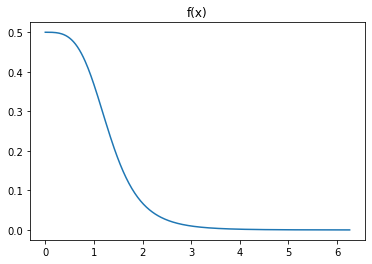

In [16]:
xs = [float(i/50) for i in range(int(50*PI*2))]
ys = [f_of_x(x) for x in xs]
plt.plot(xs,ys)
plt.title("f(x)");

Ok, so we can see that our function is mostly active in the rough range of [0,3-ish] and is mostly inactive on the range [3-ish, inf]. So, let’s see if we can find a function template that can be parameterized to replicate this quality. Deb’s proposes this function: exp(-lambda*x)

The algorithm will look like this:

Start at λ = 0.05

Calculate the variance

Increment λ

Repeat steps 2 and 3 until you reach the last λ

Pick the λ with the lowest variance — this is your optimal λ

Use importance sampling Monte Carlo with this λ to calculate the integral

In [18]:
# this is the template of our weight function g(x)
def g_of_x(x, A, lamda):
    e = 2.71828
    return A*math.pow(e, -1*lamda*x)

def inverse_G_of_r(r, lamda):
    return (-1 * math.log(float(r)))/lamda

def get_IS_variance(lamda, num_samples):
    """
    This function calculates the variance if a Monte Carlo
    using importance sampling.
    Args:
    - lamda (float) : lamdba value of g(x) being tested
    Return: 
    - Variance
    """
    A = lamda
    int_max = 5
    
    # get sum of squares
    running_total = 0
    for i in range(num_samples):
        x = get_rand_number(0, int_max)
        running_total += (f_of_x(x)/g_of_x(x, A, lamda))**2
    
    sum_of_sqs = running_total / num_samples
    
    # get squared average
    running_total = 0
    for i in range(num_samples):
        x = get_rand_number(0, int_max)
        running_total += f_of_x(x)/g_of_x(x, A, lamda)
    sq_ave = (running_total/num_samples)**2
    
    
    return sum_of_sqs - sq_ave

# get variance as a function of lambda by testing many
# different lambdas

test_lamdas = [i*0.05 for i in range(1, 61)]
variances = []

for i, lamda in enumerate(test_lamdas):
    print(f"lambda {i+1}/{len(test_lamdas)}: {lamda}")
    A = lamda
    variances.append(get_IS_variance(lamda, 100000))
    clear_output(wait=True)
    
optimal_lamda = test_lamdas[np.argmin(np.asarray(variances))]
IS_variance = variances[np.argmin(np.asarray(variances))]

print(f"Optimal Lambda: {optimal_lamda}")
print(f"Optimal Variance: {IS_variance}")
print(f"Error: {(IS_variance/10000)**0.5}")

Optimal Lambda: 1.6500000000000001
Optimal Variance: 0.04634323947161856
Error: 0.002152747998991488


In [19]:
# all we have to do is run the simulation with our optimized g(x) function
def importance_sampling_MC(lamda, num_samples):
    A = lamda
    
    running_total = 0
    for i in range(num_samples):
        r = get_rand_number(0,1)
        running_total += f_of_x(inverse_G_of_r(r, lamda=lamda))/g_of_x(inverse_G_of_r(r, lamda=lamda), A, lamda)
    approximation = float(running_total/num_samples)
    return approximation

# run simulation
num_samples = 10000
approx = importance_sampling_MC(optimal_lamda, num_samples)
variance = get_IS_variance(optimal_lamda, num_samples)
error = (variance/num_samples)**0.5

# display results
print(f"Importance Sampling Approximation: {approx}")
print(f"Variance: {variance}")
print(f"Error: {error}")

Importance Sampling Approximation: 0.6990210666879653
Variance: 0.04465363461322425
Error: 0.0021131406629286242
